# 10v6_00 — Test-matched validation diagnostic (label-free)

**This is a question, not an assumption.** Under `mirror_aware` TL_EVAL validation the frozen
spectrum model scored far lower than under `test_simulated_strict`. The difference comes almost
entirely from *which reference spectra are allowed*. Does `test_simulated_strict` resemble how
the hidden test relates to the training spectral library? Or does it admit unusually close
sibling spectra that hidden-test molecules will not have?

The relationship between a query spectrum and the **training library** is observable for the
visible TEST without any label. The same statistic can be computed for TL_EVAL under each
protocol and compared.

* **Statistic** (`casmi.validation.test_match`). `max_cosine` is the maximum cosine over the
  *ranker-visible* pairs: for every mass-window candidate, the first 5 eligible references in
  compat order, which are exactly the references behind the frozen features. It uses the same
  cleaning, deterministic top-N, kernels and retrieval everywhere. The only difference between
  populations is the eligibility filter.
* **Populations.** TEST uses the production `casmi_infer` path (`exclude_sources = {}`, T1 by
  peak hash, T2 not applied). TL_EVAL uses `test_simulated_strict` and `mirror_aware`
  (`standard` is an optimistic sensitivity) as QCR filters. HOST is optional and contextual.
* **No labels.** QCR shards and pools are read with label-free column lists. TEST truth does not
  exist here, and TL truth is never loaded. The resemblance rule accepts only label-free
  distances; model MRR cannot reach it.
* **Decision.** The rule is pre-registered in section 1 **before** any statistic is computed. It
  is not changed after execution.

The frozen model is **not** modified. Its record gains only `validation_realism_status`.

In [1]:
import sys, json
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src').exists() and (REPO_ROOT.parent / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from casmi.paths import get_project_paths
from casmi.qcr.context import v4b_paths, v5_paths
from casmi.qcr.settlement import load_settlement_or_refuse
from casmi.ranking.freeze import require_frozen_spectrum_model
from casmi.ranking.selection import write_preregistration
from casmi.validation import test_match as tm
from casmi.validation.realism import (PENDING, annotate_freeze_realism, primary_eval_protocols, scaling_interpretation,
                                      validation_interpretation)

paths = get_project_paths()
vp, D = v4b_paths(paths), v5_paths(paths)
OUT = paths.outputs / 'v6' / 'test_match'
FIG, CACHE = OUT / 'figures', OUT / 'cache'
for p in (OUT, FIG, CACHE):
    p.mkdir(parents=True, exist_ok=True)

INCLUDE_STANDARD = True      # optimistic sensitivity (never decisive)
INCLUDE_HOST = True          # contextual only (never decisive)
N_PARITY = 100               # TL_EVAL queries re-derived through the TEST producer (0 disables the parity cell)
TEST_LIMIT = None            # e.g. 200 for a smoke run; None = every visible test spectrum

FREEZE_PATH = D['freeze'] / 'spectrum_model.json'
freeze = require_frozen_spectrum_model(FREEZE_PATH)      # verifies model hashes; the model is not used below
if 'validation_realism_status' not in freeze:        # additive; never reverts a status set by an earlier run
    annotate_freeze_realism(FREEZE_PATH, PENDING, set_by='10v6_00 (start)')
print('frozen spectrum model:', freeze['model_id'], '| training protocol:', freeze.get('protocol'),
      '| recorded scaling status (unchanged):', freeze.get('scaling_status'))

frozen spectrum model: V1_TL_1K_TESTSIM_STRICT | training protocol: test_simulated_strict | recorded scaling status (unchanged): PLATEAU


## 1. Pre-registration: written **before** any statistic exists

`write_preregistration` refuses to overwrite a different rule. After the first run the thresholds
cannot drift.

In [2]:
PREREG_PATH = OUT / 'preregistration_test_match.json'
prereg = write_preregistration(PREREG_PATH, rule=tm.RESEMBLANCE_RULE)
print('resemblance rule sha256:', prereg['rule_sha256'])
print(json.dumps(tm.RESEMBLANCE_RULE['decision'], indent=1))

resemblance rule sha256: 90120968edb94da7a3b4ebad0f091a872246e0f82a759fe208051d2fadb92a32
[
 "if |KS_strict - KS_mirror| <= primary_tie_tolerance -> INTERMEDIATE_OR_INCONCLUSIVE",
 "closer = protocol with the smaller primary KS; if that KS > max_primary_distance_for_resemblance -> INTERMEDIATE_OR_INCONCLUSIVE (TEST far from both)",
 "each supporting comparison votes for the protocol with the smaller distance (exact ties abstain)",
 "if >= 2 of the 3 supporting votes go to the OTHER protocol (majority contradiction) -> INTERMEDIATE_OR_INCONCLUSIVE",
 "else closer == strict -> STRICT_LIKE; closer == mirror -> MIRROR_LIKE"
]


## 2. TEST under production inference semantics (`test_observed`)

The bundle is loaded with full sha256 verification. Every visible test spectrum runs through the
production retrieval and reference selection, using the NUMPY kernels, which are the training
`compute_single_pair_scores`. Results are chunk-cached under `cache/test_pairs/`. Only observable
fields are read. The bundle's reference library must be the TRAIN library the QCR was built
against (asserted below).

In [3]:
from casmi_infer.pipeline import Bundle
bundle = Bundle(D['bundle'], verify=True)
REF_META = bundle.lib.meta[['ref_spectrum_id', 'source', 'instrument', 'adduct', 'collision_energy', 'precursor_mz']]
settlement = load_settlement_or_refuse(vp.settlement_json)
cfg_sim, bundle_sim = settlement['similarity_config'], bundle.config['similarity']
assert all(bundle_sim[k] == cfg_sim[k] for k in ('bin_width_da', 'peak_tol_da', 'max_peaks_similarity')), 'bundle similarity config != QCR evidence config'
assert bundle.config['top_reference_count'] == tm.TOP_K

test_df = pd.read_parquet(paths.test)
tm.assert_label_free(test_df, 'visible test')
t_pairs, t_pool, t_meta, t_log = tm.run_observed_test(bundle, test_df, CACHE / 'test_pairs', limit=TEST_LIMIT)
TEST_STATS = tm.finalize_query_stats(tm.query_stats_from_pairs(t_pairs, t_pool, t_meta), 'TEST', tm.TEST_OBSERVED, REF_META)
print(f"TEST: {len(TEST_STATS)} spectra, {TEST_STATS['molecule_id'].nunique()} molecules | retrieval levels:",
      TEST_STATS['retrieval_level'].value_counts().to_dict(), '| unsupported adducts:', t_log.unsupported_adducts)

TEST: 1213 spectra, 400 molecules | retrieval levels: {'primary': 1213} | unsupported adducts: {}


## 3. TL_EVAL under each protocol (a filter of the existing QCR; no similarity is recomputed)

For every non-`mirror_aware` protocol the walk-completeness argument is re-checked on the data
(`assert_walk_complete`). Query metadata comes from the exported reference table: TL_EVAL
queries are training spectra, `ref_row` equals the train row offset, and the neutral mass comes
from the bundle adduct rules.

In [4]:
from casmi.ranking.manifests import load_manifest
tl_ids = sorted(load_manifest('TL_EVAL', D['manifests'])[0]['query_id'].astype(str))     # ONLY the id column is kept
unit = D['qcr'] / 'TL_EVAL'
qcr_paths, pair_paths = sorted((unit / 'qcr' / 'shards').glob('part-*.parquet')), sorted((unit / 'qcr_pairs' / 'shards').glob('part-*.parquet'))
if not qcr_paths:
    raise RuntimeError('TL_EVAL QCR missing. Run: PYTHONPATH=src PYTHONNOUSERSITE=1 python scripts/v5_build_scale_features.py --manifest TL_EVAL')
tl_pool = tm.read_label_free_pool(D['features'] / 'units' / 'TL_EVAL_pool.parquet', tl_ids)
tl_meta = tm.library_query_meta(bundle, tl_ids)

PROTOCOLS = [tm.STRICT, tm.MIRROR] + ([tm.STANDARD] if INCLUDE_STANDARD else [])
TL_STATS, TL_PAIRS = {}, {}
for p in PROTOCOLS:
    TL_PAIRS[p] = tm.qcr_protocol_pairs(qcr_paths, p, pool=tl_pool, pair_paths=pair_paths)
    TL_STATS[p] = tm.finalize_query_stats(tm.query_stats_from_pairs(TL_PAIRS[p], tl_pool, tl_meta), 'TL_EVAL', p, REF_META)
    print(f"TL_EVAL {p}: {len(TL_STATS[p])} queries, {len(TL_PAIRS[p]):,} ranker-visible pairs")
# identical query set and pools across protocols: ONLY the eligibility filter differs
assert all((TL_STATS[p]['query_id'].to_numpy() == TL_STATS[tm.STRICT]['query_id'].to_numpy()).all() for p in PROTOCOLS)
assert all((TL_STATS[p]['candidate_pool_size'].to_numpy() == TL_STATS[tm.STRICT]['candidate_pool_size'].to_numpy()).all() for p in PROTOCOLS)

c:\Users\myben\OneDrive\Documents\Enveda\src\casmi\qcr\protocols.py:293: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  c["exhausted"] = c["exhausted"].fillna(True).astype(bool)


TL_EVAL test_simulated_strict: 1000 queries, 1,574,279 ranker-visible pairs
TL_EVAL mirror_aware: 1000 queries, 293,077 ranker-visible pairs


c:\Users\myben\OneDrive\Documents\Enveda\src\casmi\qcr\protocols.py:293: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  c["exhausted"] = c["exhausted"].fillna(True).astype(bool)


TL_EVAL standard: 1000 queries, 1,574,282 ranker-visible pairs


## 3b. HOST (optional, contextual only; never decisive)

In [5]:
HOST_STATS = {}
if INCLUDE_HOST:
    arts = settlement['evidence_artifacts']
    host_pool = tm.read_label_free_pool(arts['host_features_mirror_aware'])
    host_ids = sorted(host_pool['query_id'].astype(str).unique())
    host_meta = tm.library_query_meta(bundle, host_ids)
    for p in (tm.STRICT, tm.MIRROR):
        hp = tm.qcr_protocol_pairs([arts['host_qcr']], p, pool=host_pool, pair_paths=[arts['host_qcr_pairs']])
        HOST_STATS[p] = tm.finalize_query_stats(tm.query_stats_from_pairs(hp, host_pool, host_meta), 'HOST', p, REF_META)
        print(f"HOST {p}: {len(HOST_STATS[p])} queries")

HOST test_simulated_strict: 1184 queries
HOST mirror_aware: 1184 queries


## 3c. Parity: TL_EVAL queries re-derived through the TEST producer

The same `max_cosine` must come out of the production path, using the benchmark exclusions of the
protocol, as out of the QCR filter. The only admissible differences are T2-affected queries,
because T2 is not shipped to inference. Any other difference stops the notebook. This proves that
TEST and TL use one statistic, rather than trusting it.

In [6]:
if N_PARITY:
    from casmi_infer.backend import NUMPY, use_backend
    rng = np.random.default_rng(42)
    par_ids = sorted(rng.choice(tl_ids, size=min(N_PARITY, len(tl_ids)), replace=False).tolist())
    t2_q = set()
    for p_ in qcr_paths:
        q_ = pd.read_parquet(p_, columns=['query_id', 'tier', 'ref_source', 'query_source'])
        t2_q |= set(q_.loc[q_['tier'].astype(str) == 'T2', 'query_id'].astype(str))
    par_rows = []
    with use_backend(NUMPY):
        for p in (tm.STRICT, tm.MIRROR):
            ref = TL_STATS[p].set_index('query_id')
            for q in par_ids:
                pr, po, _ = tm.bundle_library_query_pairs(bundle, q, p)
                s = tm.query_stats_from_pairs(pr, po, tl_meta[tl_meta['query_id'] == q]).iloc[0]
                par_rows.append({'protocol': p, 'query_id': q, 'qcr_max_cosine': ref.loc[q, 'max_cosine'], 'bundle_max_cosine': s['max_cosine'],
                                 'qcr_pool': ref.loc[q, 'candidate_pool_size'], 'bundle_pool': s['candidate_pool_size'], 't2_affected': q in t2_q})
    PAR = pd.DataFrame(par_rows)
    PAR['match'] = np.isclose(PAR['qcr_max_cosine'], PAR['bundle_max_cosine'], atol=1e-9, rtol=0) & (PAR['qcr_pool'] == PAR['bundle_pool'])
    unexplained = PAR[~PAR['match'] & ~PAR['t2_affected']]
    PAR.to_csv(OUT / 'producer_parity.csv', index=False)
    print(PAR.groupby('protocol')[['match', 't2_affected']].sum(), '\nunexplained mismatches:', len(unexplained))
    assert unexplained.empty, 'TEST and TL producers disagree beyond T2 -- the statistic is NOT identical; fix before interpreting'

                       match  t2_affected
protocol                                 
mirror_aware             100            0
test_simulated_strict    100            0 
unexplained mismatches: 0


## 4. Query-level table (label-free) → `query_stats.parquet`

In [7]:
parts = [TEST_STATS, *TL_STATS.values(), *HOST_STATS.values()]
QS = pd.concat(parts, ignore_index=True)
tm.assert_label_free(QS, 'query_stats')
assert QS.loc[QS['dataset'] != 'TEST', 'molecule_id'].isna().all(), 'TL/HOST molecule ids would be truth connectivities'
QS.to_parquet(OUT / 'query_stats.parquet', index=False)
QS = tm.add_strata(QS, TEST_STATS)
TEST_S = QS[QS['population'] == tm.POP_TEST]
TL_S = {p: QS[QS['population'] == tm.population('TL_EVAL', p)] for p in PROTOCOLS}
print(QS.groupby('population').size())

population
HOST:mirror_aware                1184
HOST:test_simulated_strict       1184
TEST:test_observed               1213
TL_EVAL:mirror_aware             1000
TL_EVAL:standard                 1000
TL_EVAL:test_simulated_strict    1000
dtype: int64


## 5. Distribution summaries: RAW and TEST-REWEIGHTED → `distribution_summary.csv`

Reweighting uses only observable cells (adduct group × polarity × pool-size bin, with the
pre-registered coarser fallbacks). The TL weights are identical for every protocol, because the
queries and pools are identical.

In [8]:
W, W_INFO = tm.reweighting_weights_to_test(TL_S[tm.STRICT], TEST_S)
print('reweighting:', W_INFO)
WEIGHTS = {tm.population('TL_EVAL', p): W for p in PROTOCOLS}
SUMMARY = tm.distribution_summary(QS, WEIGHTS)
SUMMARY.to_csv(OUT / 'distribution_summary.csv', index=False)
show = ['population', 'weighting', 'n_queries', 'max_cosine_P10', 'max_cosine_P25', 'max_cosine_P50', 'max_cosine_P75', 'max_cosine_P90',
        'max_cosine_P95', 'max_cosine_P99', 'share_max_cosine_ge_0.95', 'share_max_cosine_ge_0.90', 'share_max_cosine_ge_0.80',
        'share_max_cosine_ge_0.70', 'share_max_cosine_lt_0.50', 'share_no_eligible_reference', 'matched_peaks_at_max_cosine_P50',
        'max_modified_cosine_P50', 'max_peak_overlap_P50']
display(SUMMARY[show].round(4))

reweighting: {'dims': ['adduct_group', 'polarity', 'pool_size_bin'], 'test_coverage': 0.9686727122835943, 'n_cells_used': 14, 'uncovered_test_share': 0.031327287716405694, 'min_cell': 5, 'min_coverage': 0.95, 'n_tl_zero_weight': 25}


,population,weighting,n_queries,max_cosine_P10,max_cosine_P25,max_cosine_P50,max_cosine_P75,max_cosine_P90,max_cosine_P95,max_cosine_P99,share_max_cosine_ge_0.95,share_max_cosine_ge_0.90,share_max_cosine_ge_0.80,share_max_cosine_ge_0.70,share_max_cosine_lt_0.50,share_no_eligible_reference,matched_peaks_at_max_cosine_P50,max_modified_cosine_P50,max_peak_overlap_P50
0,HOST:mirror_aware,RAW,1184,0.4781,0.6979,0.8749,0.9571,0.9844,0.9932,0.9987,0.2863,0.4434,0.6427,0.7483,0.1115,0.0,13.0,0.8743,0.42
1,HOST:test_simulated_strict,RAW,1184,0.5330,0.7477,0.8903,0.9605,0.9859,0.9932,0.9993,0.3117,0.4747,0.6858,0.7973,0.0819,0.0,17.0,0.8905,0.53
2,TEST:test_observed,RAW,1213,0.7110,0.8264,0.9174,0.9761,0.9948,0.9979,0.9996,0.3652,0.5622,0.7964,0.9093,0.0124,0.0,44.0,0.9170,0.69
3,TL_EVAL:mirror_aware,RAW,1000,0.1219,0.2586,0.4774,0.7258,0.8817,0.9440,0.9856,0.0430,0.0850,0.1790,0.2840,0.5260,0.0,6.0,0.4393,0.29
4,TL_EVAL:mirror_aware,TEST_REWEIGHTED,1000,0.1316,0.2653,0.4840,0.7384,0.8932,0.9472,0.9857,0.0480,0.0925,0.1862,0.2914,0.5225,0.0,6.0,0.4454,0.29
5,TL_EVAL:standard,RAW,1000,0.7247,0.8263,0.9228,0.9762,0.9942,0.9981,0.9997,0.3830,0.5680,0.8090,0.9280,0.0120,0.0,47.0,0.9195,0.69
6,TL_EVAL:standard,TEST_REWEIGHTED,1000,0.7269,0.8292,0.9260,0.9783,0.9947,0.9983,0.9998,0.3995,0.5770,0.8149,0.9283,0.0094,0.0,47.0,0.9258,0.69
7,TL_EVAL:test_simulated_strict,RAW,1000,0.7247,0.8263,0.9228,0.9761,0.9941,0.9980,0.9996,0.3820,0.5680,0.8090,0.9280,0.0120,0.0,47.0,0.9195,0.69
8,TL_EVAL:test_simulated_strict,TEST_REWEIGHTED,1000,0.7269,0.8292,0.9260,0.9782,0.9945,0.9981,0.9996,0.3986,0.5770,0.8149,0.9283,0.0094,0.0,47.0,0.9258,0.69


## 6. Distances: TEST vs each protocol → `protocol_distances.csv` (RAW and TEST-REWEIGHTED)

Every metric is kept, including those that disagree.

In [9]:
OTHERS = {'strict': TL_S[tm.STRICT], 'mirror': TL_S[tm.MIRROR], **({'standard': TL_S[tm.STANDARD]} if INCLUDE_STANDARD else {})}
w_arr = {k: W.reindex(o['query_id']).to_numpy(float) for k, o in OTHERS.items()}
DIST_RAW = tm.protocol_distances(TEST_S, OTHERS).assign(weighting='RAW')
DIST_RW = tm.protocol_distances(TEST_S, OTHERS, weights=w_arr).assign(weighting='TEST_REWEIGHTED')
DIST = pd.concat([DIST_RAW, DIST_RW], ignore_index=True)
DIST.to_csv(OUT / 'protocol_distances.csv', index=False)
display(DIST.round(4))

,metric,test_vs_strict_distance,test_vs_mirror_distance,test_vs_standard_distance,closer,weighting
0,ks_max_cosine,0.0347,0.6413,0.0357,strict,RAW
1,ks_max_modified_cosine,0.0354,0.6546,0.0354,strict,RAW
2,ks_matched_peaks_at_max_cosine,0.0618,0.6292,0.0628,strict,RAW
3,ks_candidate_pool_size,0.0694,0.0694,0.0694,tie,RAW
4,ks_max_peak_overlap,0.0348,0.8445,0.0338,strict,RAW
5,abs_diff_share_max_cosine_ge_0.95,0.0168,0.3222,0.0178,strict,RAW
6,abs_diff_median_matched_peaks,3.0000,38.0000,3.0000,strict,RAW
7,ks_max_cosine,0.0472,0.6338,0.0481,strict,TEST_REWEIGHTED
8,ks_max_modified_cosine,0.0492,0.6451,0.0492,strict,TEST_REWEIGHTED
9,ks_matched_peaks_at_max_cosine,0.0552,0.6310,0.0563,strict,TEST_REWEIGHTED


## 7. Stratified checks (reported, not decisive) → `stratified_distances.csv`

In [10]:
STRAT = tm.stratified_distances(TEST_S, {k: v for k, v in OTHERS.items() if k in ('strict', 'mirror')})
STRAT.to_csv(OUT / 'stratified_distances.csv', index=False)
STRAT_SUMMARY = tm.stratified_summary(STRAT)
display(STRAT.round(4)); print(STRAT_SUMMARY)

,stratum_dim,stratum,n_test,n_strict,ks_test_vs_strict,median_max_cosine_strict,n_mirror,ks_test_vs_mirror,median_max_cosine_mirror,median_max_cosine_test,status,closer
0,adduct_group,OTHER,2,4,1.0000,0.9817,4,0.7500,0.1130,0.6075,TOO_SMALL,NaN
1,adduct_group,[M+CH2O2-H]-,31,20,0.1871,0.9100,20,0.6210,0.4567,0.9391,TOO_SMALL,NaN
2,adduct_group,[M+Cl]-,2,2,1.0000,0.7135,2,1.0000,0.4017,0.9967,TOO_SMALL,NaN
3,adduct_group,[M+H]+,959,843,0.0389,0.9191,843,0.6647,0.4885,0.9199,OK,strict
4,adduct_group,[M+NH4]+,4,2,0.5000,0.7512,2,1.0000,0.1149,0.7723,TOO_SMALL,NaN
5,adduct_group,[M+Na]+,22,18,0.2424,0.8147,18,0.4747,0.2335,0.7769,TOO_SMALL,NaN
6,adduct_group,[M-H]-,193,111,0.1069,0.9382,111,0.5944,0.3929,0.9190,OK,strict
7,polarity,negative,226,133,0.0953,0.9363,133,0.5918,0.4160,0.9190,OK,strict
8,polarity,positive,987,867,0.0356,0.9188,867,0.6583,0.4848,0.9173,OK,strict
9,pool_size_bin,1-49,43,45,0.1747,0.9297,45,0.7969,0.1357,0.8726,OK,strict


{'n_strata_ok': 11, 'n_strata_strict_closer': 11, 'n_strata_mirror_closer': 0, 'test_weighted_share_strict_closer': 1.0}


## 8. Pre-registered decision (label-free distances only) → `validation_resemblance.json`

In [11]:
RI = {'RAW': {k: tm.rule_inputs(TEST_S, OTHERS[k]) for k in ('strict', 'mirror')},
      'TEST_REWEIGHTED': {k: tm.rule_inputs(TEST_S, OTHERS[k], w_arr[k]) for k in ('strict', 'mirror')}}
DEC_RAW = tm.decide_resemblance(RI['RAW']['strict'], RI['RAW']['mirror'])
DEC_RW = tm.decide_resemblance(RI['TEST_REWEIGHTED']['strict'], RI['TEST_REWEIGHTED']['mirror'])
STATUS = tm.final_resemblance(DEC_RAW, DEC_RW)
INTERP = validation_interpretation(STATUS)
SCALING = scaling_interpretation(STATUS, freeze.get('scaling_status'))


def _shares(pop, weighting='RAW'):
    r = SUMMARY[(SUMMARY['population'] == pop) & (SUMMARY['weighting'] == weighting)]
    return {} if r.empty else {c: float(r.iloc[0][c]) for c in SUMMARY.columns if c.startswith('share_')}


RESEMBLANCE = {
    'status': STATUS, 'rule_id': tm.RESEMBLANCE_RULE['rule_id'], 'preregistration_sha256': prereg['rule_sha256'],
    'decision_raw': DEC_RAW, 'decision_test_reweighted': DEC_RW, 'rule_inputs': RI,
    'distances': DIST.to_dict('records'),
    'threshold_share_comparisons': {'RAW': {pop: _shares(pop) for pop in SUMMARY['population'].unique()},
                                    'TEST_REWEIGHTED': {pop: _shares(pop, 'TEST_REWEIGHTED') for pop in WEIGHTS}},
    'stratified_checks': STRAT_SUMMARY, 'test_reweighting': W_INFO,
    'interpretation': INTERP, 'molecule_aggregation_eval_protocols': primary_eval_protocols(STATUS),
    'scaling_interpretation': SCALING,
    'frozen_model': {'model_id': freeze['model_id'], 'model_freeze_status': 'FROZEN', 'unchanged': True},
    'statistic_contract': tm.RESEMBLANCE_RULE['statistic'], 'producer_parity_csv': str(OUT / 'producer_parity.csv') if N_PARITY else None,
    'populations': sorted(QS['population'].unique()), 'labels_used': False,
}
(OUT / 'validation_resemblance.json').write_text(json.dumps(RESEMBLANCE, indent=2, default=str), encoding='utf-8')
(OUT / 'scaling_interpretation.json').write_text(json.dumps(SCALING, indent=2, default=str), encoding='utf-8')
annotate_freeze_realism(FREEZE_PATH, STATUS, evidence={'validation_resemblance': str(OUT / 'validation_resemblance.json'),
                                                       'rule_sha256': prereg['rule_sha256']})
print('VALIDATION RESEMBLANCE:', STATUS, '| raw:', DEC_RAW['status'], '| reweighted:', DEC_RW['status'])

VALIDATION RESEMBLANCE: STRICT_LIKE | raw: STRICT_LIKE | reweighted: STRICT_LIKE


## 9. Molecule-level TEST matchability (proxy) → `test_molecule_matchability.parquet`

One strongly library-matchable spectrum may be enough for a molecule. These are **proxies**, not
class labels.

In [12]:
MOL = tm.molecule_matchability(TEST_S)
MOL.to_parquet(OUT / 'test_molecule_matchability.parquet', index=False)
MOL_SHARES = tm.molecule_matchability_shares(MOL)
PROXIES = tm.library_matchability_proxies(TEST_S)
display(MOL.describe().round(3)); print(json.dumps(MOL_SHARES, indent=1))
RESEMBLANCE.update(library_matchability_proxy_spectrum=PROXIES, library_matchability_proxy_molecule=MOL_SHARES)
(OUT / 'validation_resemblance.json').write_text(json.dumps(RESEMBLANCE, indent=2, default=str), encoding='utf-8')

,n_spectra,max_spectrum_max_cosine,mean_max_cosine,median_max_cosine,n_spectra_ge_0.95,n_spectra_ge_0.80,n_spectra_lt_0.50
count,400.000,400.000,400.000,400.000,400.000,400.000,400.000
mean,3.032,0.930,0.876,0.886,1.108,2.415,0.038
std,1.382,0.096,0.104,0.110,1.286,1.394,0.203
min,1.000,0.158,0.158,0.158,0.000,0.000,0.000
25%,2.000,0.910,0.830,0.845,0.000,1.000,0.000
50%,3.000,0.959,0.901,0.916,1.000,2.000,0.000
75%,4.000,0.990,0.951,0.964,2.000,4.000,0.000
max,9.000,1.000,1.000,1.000,5.000,8.000,2.000


{
 "n_molecules": 400,
 "wording": "proxy (label-free): best-spectrum max library cosine per molecule",
 "share_HIGH": 0.925,
 "share_MEDIUM": 0.0675,
 "share_LOW": 0.0075,
 "share_best_spectrum_ge_0.95": 0.5525,
 "share_with_any_spectrum_lt_0.50": 0.035
}


12395

## 10. Figures (six diagnostic plots)

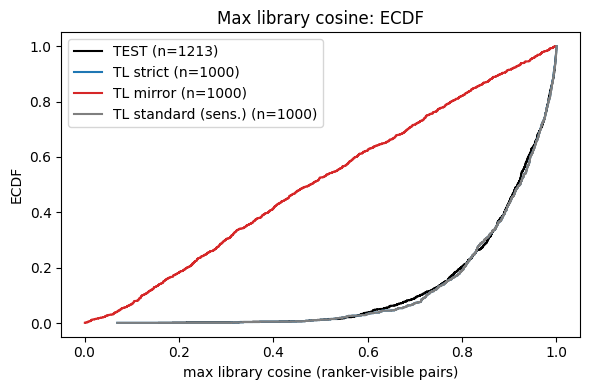

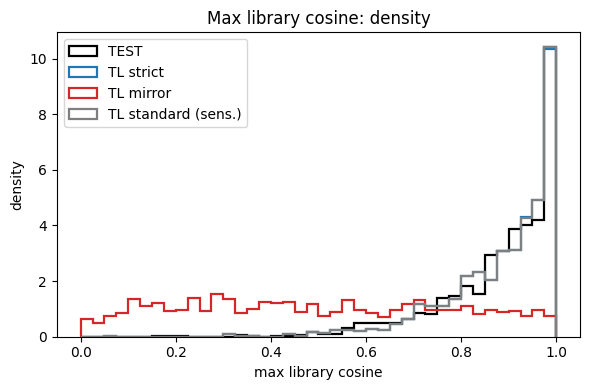

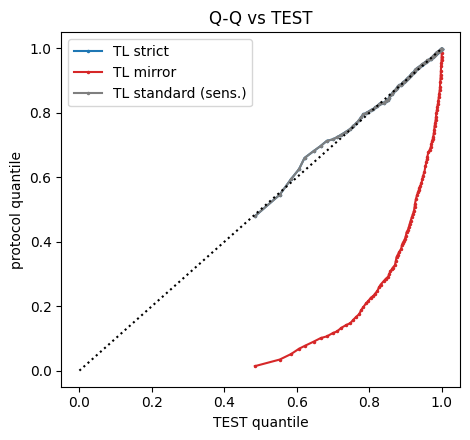

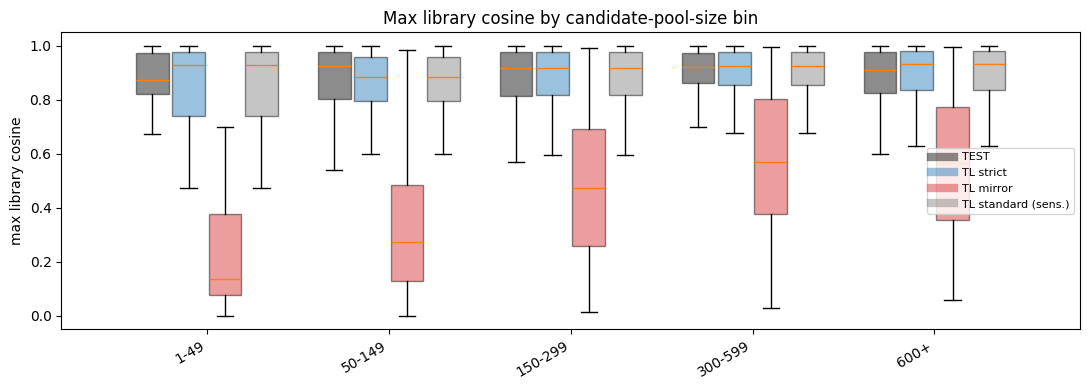

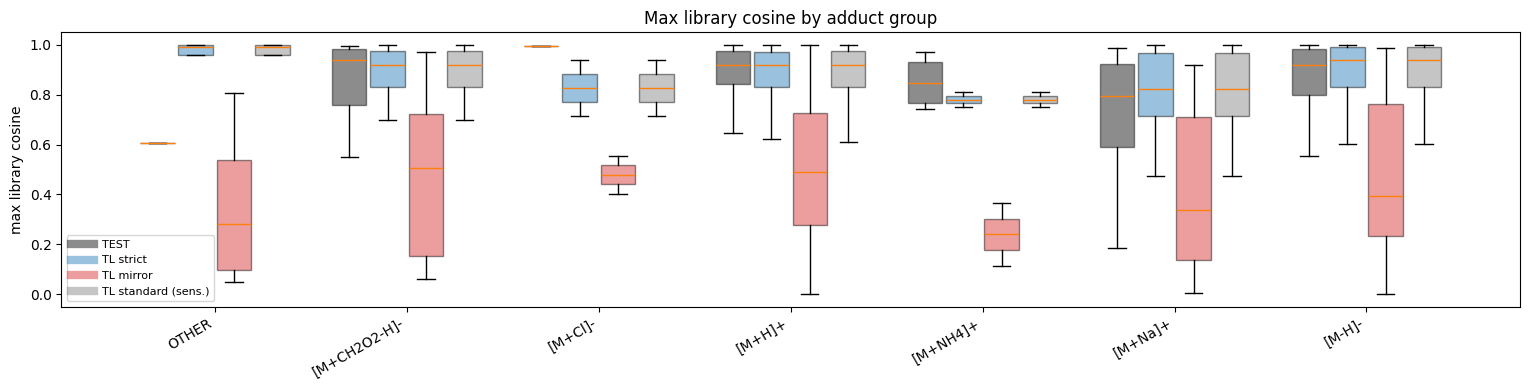

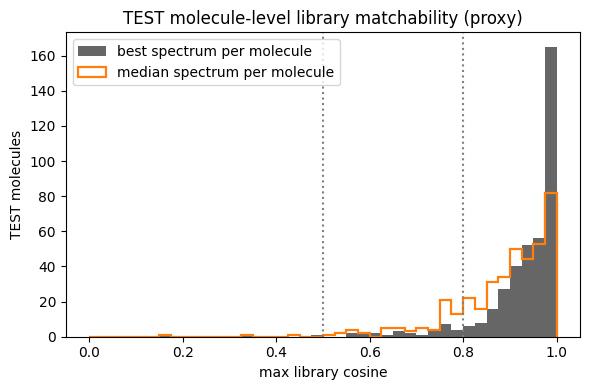

In [13]:
POPS = [(tm.POP_TEST, 'TEST', 'k'), (tm.POP_STRICT, 'TL strict', 'tab:blue'), (tm.POP_MIRROR, 'TL mirror', 'tab:red')]
if INCLUDE_STANDARD:
    POPS.append((tm.POP_STANDARD, 'TL standard (sens.)', 'tab:gray'))
data = {lab: QS.loc[QS['population'] == pop, 'max_cosine'].to_numpy(float) for pop, lab, _ in POPS}

fig, ax = plt.subplots(figsize=(6, 4))                                    # 1. ECDF
for pop, lab, col in POPS:
    v = np.sort(data[lab]); ax.step(v, np.arange(1, len(v) + 1) / max(len(v), 1), where='post', label=f'{lab} (n={len(v)})', color=col)
ax.set_xlabel('max library cosine (ranker-visible pairs)'); ax.set_ylabel('ECDF'); ax.legend(); ax.set_title('Max library cosine: ECDF')
fig.tight_layout(); fig.savefig(FIG / '1_ecdf_max_cosine.png', dpi=130); plt.show()

fig, ax = plt.subplots(figsize=(6, 4))                                    # 2. histogram (density)
bins = np.linspace(0, 1, 41)
for pop, lab, col in POPS:
    ax.hist(data[lab], bins=bins, density=True, histtype='step', lw=1.6, label=lab, color=col)
ax.set_xlabel('max library cosine'); ax.set_ylabel('density'); ax.legend(); ax.set_title('Max library cosine: density')
fig.tight_layout(); fig.savefig(FIG / '2_hist_max_cosine.png', dpi=130); plt.show()

fig, ax = plt.subplots(figsize=(4.8, 4.5))                                # 3. quantile-quantile vs TEST
qs = np.linspace(0.01, 0.99, 99)
tq = [tm.weighted_quantile(data['TEST'], q) for q in qs]
for pop, lab, col in POPS[1:]:
    ax.plot(tq, [tm.weighted_quantile(data[lab], q) for q in qs], '.-', ms=3, label=lab, color=col)
ax.plot([0, 1], [0, 1], 'k:'); ax.set_xlabel('TEST quantile'); ax.set_ylabel('protocol quantile'); ax.legend(); ax.set_title('Q-Q vs TEST')
fig.tight_layout(); fig.savefig(FIG / '3_qq_vs_test.png', dpi=130); plt.show()


def _box_by(dim, fname, title):
    levels = [l for l in (tm.POOL_SIZE_LABELS if dim == 'pool_size_bin' else sorted(TEST_S[dim].astype(str).unique())) if (TEST_S[dim] == l).any()]
    fig, ax = plt.subplots(figsize=(max(6, 1.1 * len(levels) * len(POPS) / 2), 4))
    width = 0.8 / len(POPS)
    for j, (pop, lab, col) in enumerate(POPS):
        sub = QS[QS['population'] == pop]
        vals = [sub.loc[sub[dim].astype(str) == l, 'max_cosine'].to_numpy(float) for l in levels]
        pos = np.arange(len(levels)) + (j - (len(POPS) - 1) / 2) * width
        bp = ax.boxplot([v if len(v) else [np.nan] for v in vals], positions=pos, widths=width * 0.9, patch_artist=True, showfliers=False)
        for b in bp['boxes']:
            b.set_facecolor(col); b.set_alpha(0.45)
        ax.plot([], [], color=col, lw=6, alpha=0.45, label=lab)
    ax.set_xticks(np.arange(len(levels))); ax.set_xticklabels(levels, rotation=30, ha='right'); ax.set_ylabel('max library cosine')
    ax.set_title(title); ax.legend(fontsize=8); fig.tight_layout(); fig.savefig(FIG / fname, dpi=130); plt.show()


_box_by('pool_size_bin', '4_max_cosine_by_pool_size.png', 'Max library cosine by candidate-pool-size bin')   # 4
_box_by('adduct_group', '5_max_cosine_by_adduct.png', 'Max library cosine by adduct group')                  # 5

fig, ax = plt.subplots(figsize=(6, 4))                                    # 6. molecule-level best-spectrum max cosine
ax.hist(MOL['max_spectrum_max_cosine'], bins=bins, color='k', alpha=0.6, label='best spectrum per molecule')
ax.hist(MOL['median_max_cosine'], bins=bins, histtype='step', color='tab:orange', lw=1.6, label='median spectrum per molecule')
for x in (tm.MATCH_LOW, tm.MATCH_HIGH):
    ax.axvline(x, color='gray', ls=':')
ax.set_xlabel('max library cosine'); ax.set_ylabel('TEST molecules'); ax.legend(); ax.set_title('TEST molecule-level library matchability (proxy)')
fig.tight_layout(); fig.savefig(FIG / '6_molecule_best_spectrum_max_cosine.png', dpi=130); plt.show()

## 11. Runtime decision summary

In [14]:
RAW_SUMMARY = SUMMARY[SUMMARY['weighting'] == 'RAW']
print(tm.format_diagnostic_report(RAW_SUMMARY, DIST_RAW, STATUS, PROXIES, INTERP + [SCALING['scaling_label'] + ': ' + SCALING['text']]))
print('\nMolecule-level proxy:', json.dumps(MOL_SHARES, indent=1))
print('\nReweighted decision:', DEC_RW['status'], '|', DEC_RW['reason'])
print('Stratified (reported only):', STRAT_SUMMARY)

TEST MATCH DIAGNOSTIC

TEST:
  n = 1213
  median max cosine = 0.9174
  P90 = 0.9948
  share >= 0.95 = 0.3652
  share >= 0.80 = 0.7964
  share < 0.50 = 0.0124

TL STRICT:
  n = 1000
  median max cosine = 0.9228
  P90 = 0.9941
  share >= 0.95 = 0.3820
  share >= 0.80 = 0.8090
  share < 0.50 = 0.0120

TL MIRROR:
  n = 1000
  median max cosine = 0.4774
  P90 = 0.8817
  share >= 0.95 = 0.0430
  share >= 0.80 = 0.1790
  share < 0.50 = 0.5260

DISTANCES (KS max cosine):
  TEST<->STRICT = 0.0347
  TEST<->MIRROR = 0.6413

VALIDATION RESEMBLANCE:
  STRICT_LIKE

LIBRARY-MATCHABILITY PROXY (not a Class-1 fraction):
  wording: proxy for direct-library-matchable spectra (label-free; not a true Class-1 fraction)
  n_spectra: 1213
  very_high_match_share (max_cosine>=0.95) = 0.3652
  high_match_share (max_cosine>=0.80) = 0.7964
  low_match_share (max_cosine<0.50) = 0.0124
  no_eligible_reference_share = 0.0000
  near_duplicate_proxy_share (T3-like: cos>0.95 & |dprecursor|<0.01 Da) = 0.3124
  t1_peak_h

## 12. v6.1: exact-library-identity audit → `exact_identity_audit.parquet`

The executed run printed `exact_library_duplicate_share = 1.0000`. That value was
`mean(n_t1_excluded_refs > 0)`: the share of TEST spectra for which **≥ 1 TRAIN reference of any
mass-window candidate has the query's T1 peak hash**. The hash rounds m/z to 4 decimals, the
max-normalised intensity to 3 and the precursor to 3. It is **hash-level**. It is neither array
identity nor molecule identity, so the name has been retired
(`t1_peak_hash_hit_in_candidate_refs_share`).

This audit (`casmi.validation.library_identity_audit`) takes each visible-TEST spectrum through
these steps:

1. Its hash is computed with the production `query_peak_hash`.
2. It is looked up in a **TRAIN-only** hash index built from bundle `ref_meta.peak_hash`. The index
   is asserted: ids are `train_<row>`, rows match train.parquet, and no TEST id is present.
3. Every hash match is counted anywhere in TRAIN and inside the candidate pool. The in-pool count
   must reproduce the executed `n_t1_excluded_refs` exactly.
4. Up to 25 matches are compared at the float64 **array** level against train.parquet identity
   peaks. The comparison covers m/z, intensity, full array, precursor, adduct, CE and instrument.
   The bundle hash is re-derived from those peaks to catch row misalignment.

`possible_contamination_flag` requires **full arrays + precursor identical**. Hash equality alone
never sets it. `train_connectivity_key` is the TRAIN spectrum's annotation, reported for audit.
It is **not** a TEST label and nothing downstream may use it as one.

Needs sections 0 and 2 only (`bundle`, `test_df`, `t_pool`, `t_meta`, `TEST_STATS`). The TEST
pairs are reused from the chunk cache.

In [15]:
from casmi.io.parquet import count_rows
from casmi.validation import library_identity_audit as lia

AUDIT_TEST = test_df[test_df['spectrum_id'].astype(str).isin(set(TEST_STATS['query_id']))]    # same spectra as section 2 (honours TEST_LIMIT)
N_TRAIN_ROWS = count_rows(paths.train)
print('TRAIN-only reference index:', lia.assert_train_only_reference_index(bundle.lib, AUDIT_TEST['spectrum_id'].astype(str), n_train_rows=N_TRAIN_ROWS))
AUDIT, AUDIT_MATCHES, HASH_INDEX = lia.audit_test_identity(
    bundle.lib, AUDIT_TEST, paths.train, bundle.sim_cfg['max_peaks_similarity'], n_train_rows=N_TRAIN_ROWS,
    test_pool=t_pool,                                                          # -> in-candidate-pool hash matches (legacy definition)
    legacy_t1=t_meta.set_index('query_id')['n_t1_excluded_refs'],             # parity with the executed diagnostic
    best_reference=TEST_STATS.set_index('query_id')['best_reference_id'])     # comparison partner when there is no hash match
lia.assert_audit_integrity(AUDIT, HASH_INDEX, AUDIT_TEST['spectrum_id'])
AUDIT.to_parquet(OUT / 'exact_identity_audit.parquet', index=False)
AUDIT_MATCHES.to_parquet(OUT / 'exact_identity_matches.parquet', index=False)
print('hash index:', HASH_INDEX.bucket_size_summary(), '| audit rows:', len(AUDIT), '| compared pairs:', len(AUDIT_MATCHES))

TRAIN-only reference index: {'reference_universe': 'TRAIN_ONLY', 'n_reference_spectra': 2539608, 'n_train_rows': 2539608, 'n_test_ids_checked': 1213, 'n_test_ids_in_reference_index': 0, 'id_pattern': '^train_(\\d+)$'}
[identity audit] 250/1213 TEST spectra
[identity audit] 500/1213 TEST spectra
[identity audit] 750/1213 TEST spectra
[identity audit] 1000/1213 TEST spectra
hash index: {'n_hashed_refs': 2539608, 'n_distinct_hashes': 2518925, 'n_null_hash': 0, 'n_refs_in_multi_member_buckets': 41329, 'largest_bucket_sizes': [4, 4, 4, 4, 4]} | audit rows: 1213 | compared pairs: 1215


In [16]:
ID_SUMMARY = lia.identity_audit_summary(AUDIT, HASH_INDEX)
ID_VERDICT = lia.interpret_identity_audit(ID_SUMMARY)
(OUT / 'exact_identity_audit_summary.json').write_text(json.dumps({**ID_SUMMARY, 'verdict': ID_VERDICT}, indent=2, default=str), encoding='utf-8')
print(lia.format_identity_report(ID_SUMMARY, ID_VERDICT))
display(AUDIT.groupby('identity_relation')[['hash_equal', 'full_peak_array_equal', 'precursor_mz_equal', 'adduct_equal',
                                             'collision_energy_equal', 'instrument_equal', 'possible_contamination_flag']].mean().round(4))

EXACT-LIBRARY-IDENTITY AUDIT (visible TEST vs TRAIN reference universe)

TEST spectra: 1213 | molecules: 400
reference universe: TRAIN_ONLY (2539608 spectra); TEST ids in index: 0.0000
hash match in candidate pool (legacy definition): 1.0000  | parity vs executed n_t1: 1213/1213
hash match anywhere in TRAIN:                     1.0000
exact library duplicate (full_peak_array_equal & precursor_mz_equal (NOT hash equality)): 1.0000
hash equal, arrays differ:                        0.0000
degenerate (peak-free) query hash:                0.0000
hash bucket spans >1 TRAIN connectivity:          0.0016
identity relations: {'FULL_ARRAY_IDENTICAL': 1213}
molecule level: {'share_molecules_any_spectrum_exact_duplicate': 1.0, 'share_molecules_all_spectra_exact_duplicate': 1.0}

VERDICT: VISIBLE_TEST_SPECTRA_PRESENT_IN_TRAIN_LIBRARY   | protocol work: CLOSED   | resemblance scope: VISIBLE_TEST_ONLY
  - legacy 'exact_library_duplicate_share' (retired name) == share_train_hash_match_in_candidate_po

,hash_equal,full_peak_array_equal,precursor_mz_equal,adduct_equal,collision_energy_equal,instrument_equal,possible_contamination_flag
identity_relation,,,,,,,
FULL_ARRAY_IDENTICAL,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [17]:
print('20 deterministic examples (round-robin over identity relation, sha256(spectrum_id) order):\n')
for _, r in lia.deterministic_sample(AUDIT, n=20).iterrows():
    print(lia.format_identity_example(r)); print('-' * 100)

20 deterministic examples (round-robin over identity relation, sha256(spectrum_id) order):

TEST spectrum      s_dde70760  (molecule m_5da1ef)  relation=FULL_ARRAY_IDENTICAL  basis=train_hash_match
matched TRAIN      train_932005  (hash matches in TRAIN: 1, distinct TRAIN connectivities among them: 1)
source             enveda-180
instrument         TEST timsTOF | TRAIN timsTOF  equal=True
adduct             TEST [M+H]+ | TRAIN [M+H]+  equal=True
CE (eV)            TEST 60.00 | TRAIN 60.00  equal=True
precursor m/z      TEST 314.18700 | TRAIN 314.18700  equal=True
peak counts        TEST 435 | TRAIN 435
hash equal?        True   degenerate query hash? False
full arrays equal? True  (m/z True, intensity True; max |dmz| 0.00e+00, max |dint| 0.00e+00)
possible contamination (same measurement in TRAIN): True
----------------------------------------------------------------------------------------------------
TEST spectrum      s_8d9066a9  (molecule m_47e099)  relation=FULL_ARRAY_IDENTICAL  

## 13. v6.1: multi-spectrum connectivity consensus (TEST, label-free) → `test_connectivity_consensus*.parquet`

For each spectrum, the label-free best library match is `best_candidate_connectivity`: the candidate
that owns the max-cosine ranker-visible pair. For each visible-TEST molecule, the notebook asks
whether its spectra point to the same connectivity. It reports unanimous, majority and split
molecules, and flags a *confident conflict* when two spectra with cosine ≥ 0.80 disagree. It also
computes leave-one-out agreement, binned by the spectrum's own max cosine. This measures
**consistency, not accuracy**. No truth is read, no score is read, and the TRAIN annotation of a
duplicate never enters. The only audit input is the TRAIN-side flag
`any_spectrum_exact_duplicate`, which is used to stratify. The summary informs molecule
aggregation (`11_02`) and never selects anything here.

Needs sections 0 and 2 (`TEST_STATS`, `t_pool`) and section 12 (`AUDIT`).

{
 "wording": "label-free CONSISTENCY of the best-library-match connectivity across a molecule's spectra; agreement is NOT accuracy",
 "confident_cosine": 0.8,
 "n_molecules": 400,
 "n_multi_spectrum_molecules": 345,
 "consensus_class_counts": {
  "NO_REFERENCE": 0,
  "SINGLE_SPECTRUM": 55,
  "UNANIMOUS": 107,
  "MAJORITY": 103,
  "SPLIT": 135
 },
 "share_unanimous_multi": 0.3101449275362319,
 "share_majority_or_unanimous_multi": 0.6086956521739131,
 "share_split_multi": 0.391304347826087,
 "share_confident_conflict_multi": 0.5072463768115942,
 "share_best_spectrum_agrees_with_modal_multi": 0.8318840579710145,
 "modal_share_quantiles_multi": {
  "P10": 0.3333333333333333,
  "P25": 0.5,
  "P50": 0.6666666666666666,
  "P75": 1.0
 },
 "by_n_voting_spectra": {
  "2": {
   "n": 97,
   "share_unanimous": 0.5051546391752577,
   "share_split": 0.4948453608247423,
   "share_confident_conflict": 0.24742268041237114
  },
  "3": {
   "n": 99,
   "share_unanimous": 0.2222222222222222,
   "share_spl

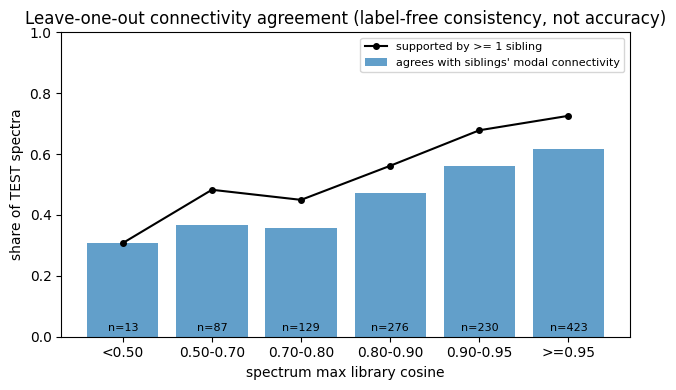

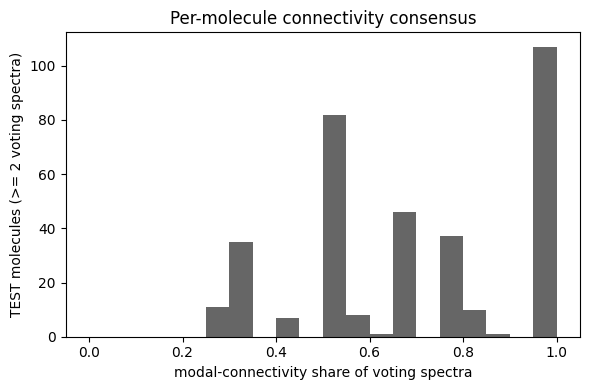

In [18]:
CONS_MOL, CONS_SPEC = tm.connectivity_consensus(TEST_STATS, pool=t_pool)
CONS_SUMMARY = tm.connectivity_consensus_summary(CONS_MOL, CONS_SPEC)
# audit context (label-free, TRAIN-side flag only): does consensus differ for molecules whose measurements are in TRAIN?
_dup = AUDIT.groupby('molecule_id')['possible_contamination_flag'].any().rename('any_spectrum_exact_duplicate')
CONS_MOL = CONS_MOL.merge(_dup, left_on='molecule_id', right_index=True, how='left')
_multi = CONS_MOL[CONS_MOL['n_with_reference'] >= 2]
CONS_SUMMARY['by_any_spectrum_exact_duplicate'] = {
    str(k): {'n': int(len(g)), 'share_unanimous': float((g['consensus_class'] == 'UNANIMOUS').mean()),
             'share_split': float((g['consensus_class'] == 'SPLIT').mean())}
    for k, g in _multi.groupby(_multi['any_spectrum_exact_duplicate'].fillna(False).astype(bool))}
CONS_MOL.to_parquet(OUT / 'test_connectivity_consensus.parquet', index=False)
CONS_SPEC.to_parquet(OUT / 'test_connectivity_consensus_spectra.parquet', index=False)
(OUT / 'connectivity_consensus_summary.json').write_text(json.dumps(CONS_SUMMARY, indent=2, default=str), encoding='utf-8')
print(json.dumps(CONS_SUMMARY, indent=1, default=str))

fig, ax = plt.subplots(figsize=(6.5, 4))                                  # 7. LOO agreement by the spectrum's own max cosine
loo = pd.DataFrame(CONS_SUMMARY['loo_agreement_by_cosine_bin']).T
ax.bar(loo.index, loo['share_loo_agrees'], color='tab:blue', alpha=0.7, label='agrees with siblings\' modal connectivity')
ax.plot(loo.index, loo['share_supported_by_any_other'], 'ko-', ms=4, label='supported by >= 1 sibling')
for i, n in enumerate(loo['n']):
    ax.text(i, 0.02, f'n={int(n)}', ha='center', fontsize=8)
ax.set_ylim(0, 1); ax.set_xlabel('spectrum max library cosine'); ax.set_ylabel('share of TEST spectra')
ax.set_title('Leave-one-out connectivity agreement (label-free consistency, not accuracy)'); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / '7_loo_connectivity_agreement_by_cosine.png', dpi=130); plt.show()

fig, ax = plt.subplots(figsize=(6, 4))                                    # 8. modal share per multi-spectrum molecule
ax.hist(_multi['modal_share'], bins=np.linspace(0, 1, 21), color='k', alpha=0.6)
ax.set_xlabel('modal-connectivity share of voting spectra'); ax.set_ylabel('TEST molecules (>= 2 voting spectra)')
ax.set_title('Per-molecule connectivity consensus'); fig.tight_layout(); fig.savefig(FIG / '8_molecule_modal_share.png', dpi=130); plt.show()

## 14. v6.1 closure → `protocol_closure.json`

Protocol work is **closed** unless the identity audit reports a correctness failure. A correctness
failure is one of: a TEST id in the reference index, a mismatch in legacy T1 parity, bundle hashes
that do not reproduce, or degenerate hashes driving T1. The resemblance status from section 8 is
not re-decided here. `validation_resemblance.json` only gains a `v61_identity_audit` block. If a
correctness failure is found, this cell raises after writing the record.

In [19]:
CLOSURE = {
    'identity_audit_verdict': ID_VERDICT['verdict'], 'correctness_failure': ID_VERDICT['correctness_failure'],
    'protocol_work_status': ID_VERDICT['protocol_work_status'], 'resemblance_scope': ID_VERDICT['resemblance_scope'],
    'validation_resemblance_status_unchanged': json.loads((OUT / 'validation_resemblance.json').read_text(encoding='utf-8')).get('status'),
    'connectivity_consensus_summary': str(OUT / 'connectivity_consensus_summary.json'),
    'exact_identity_audit_summary': str(OUT / 'exact_identity_audit_summary.json'),
    'rule': 'protocol work is CLOSED unless the identity audit finds a correctness failure; the resemblance status is never re-decided here',
}
(OUT / 'protocol_closure.json').write_text(json.dumps(CLOSURE, indent=2, default=str), encoding='utf-8')
# additive annotation of the executed resemblance record (the status itself is not touched)
_res = json.loads((OUT / 'validation_resemblance.json').read_text(encoding='utf-8'))
_res['v61_identity_audit'] = {'verdict': ID_VERDICT['verdict'], 'resemblance_scope': ID_VERDICT['resemblance_scope'],
                              'retired_metric_name': 'exact_library_duplicate_share (hash-level; see exact_identity_audit_summary.json)'}
(OUT / 'validation_resemblance.json').write_text(json.dumps(_res, indent=2, default=str), encoding='utf-8')
print(json.dumps(CLOSURE, indent=1))
if ID_VERDICT['correctness_failure']:
    raise RuntimeError('identity audit found a CORRECTNESS FAILURE -> protocol work REOPEN_REQUIRED: ' + '; '.join(ID_VERDICT['failures']))

{
 "identity_audit_verdict": "VISIBLE_TEST_SPECTRA_PRESENT_IN_TRAIN_LIBRARY",
 "correctness_failure": false,
 "protocol_work_status": "CLOSED",
 "resemblance_scope": "VISIBLE_TEST_ONLY",
 "validation_resemblance_status_unchanged": "STRICT_LIKE",
 "connectivity_consensus_summary": "C:\\Users\\myben\\OneDrive\\Documents\\Enveda\\outputs\\v6\\test_match\\connectivity_consensus_summary.json",
 "exact_identity_audit_summary": "C:\\Users\\myben\\OneDrive\\Documents\\Enveda\\outputs\\v6\\test_match\\exact_identity_audit_summary.json",
 "rule": "protocol work is CLOSED unless the identity audit finds a correctness failure; the resemblance status is never re-decided here"
}
